In [17]:
#=== Imports ===#

import torch as pt 
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import deepxde as dde
import numpy as np
from deepxde.backend import torch as ddet   # switch to torch if needed


In [41]:
"""
███████╗ ██╗   ██╗ █████╗ ██╗      ███╗   ██╗███████╗████████╗███████╗
██╔═══██╗██║   ██║██╔══██╗██║      ████╗  ██║██╔════╝╚══██╔══╝██╔════╝
██║   ██║██║   ██║███████║██║      ██╔██╗ ██║█████╗     ██║   ███████╗
██║   ██║██║   ██║██╔══██║██║      ██║╚██╗██║██╔══╝     ██║   ╚════██║
███████╔╝╚██████╔╝██║  ██║███████╗ ██║ ╚████║███████╗   ██║   ███████║
 ╚═════╝  ╚═════╝ ╚═╝  ╚═╝╚══════╝ ╚═╝  ╚═══╝╚══════╝   ╚═╝   ╚══════╝
"""


class Sin(nn.Module):
    def forward(self, input):
        return pt.sin(input)


class SimpleMLP(nn.Module):
    """
    Feedforward MLP for the solution surface u(t, x[, y, ...]).
    input_size should equal 1 + spatial_dim. We accept variable coords in forward()
    and concatenate them (t, x[, y, ...]) along dim=1.
    """
    def __init__(self, n_layers, hidden_size, input_size=2):
        super(SimpleMLP, self).__init__()
        assert n_layers >= 2, "n_layers must be at least 2"

        layers = []
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.Tanh())

        for _ in range(n_layers - 2):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.Tanh())

        layers.append(nn.Linear(hidden_size, 1))
        self.model = nn.Sequential(*layers)

    def forward(self, *coords):
        # coords expected as (t, x) or (t, x, y, ...)
        input_tensor = pt.cat(coords, dim=1)
        return self.model(input_tensor)


class symMLP(nn.Module):
    """
    Operator network v(F). For interpretable discovery set n_layers=1 (pure linear).
    """
    def __init__(self, input_size, n_layers, hidden_size=0, linear_only=False):
        super(symMLP, self).__init__()
        assert n_layers >= 1, "n_layers must be at least 1"

        layers = []
        if n_layers == 1:
            layers.append(nn.Linear(input_size, 1, bias=True))
        else:
            layers.append(nn.Linear(input_size, hidden_size))
            if not linear_only:
                layers.append(nn.ReLU())
            for _ in range(n_layers - 2):
                layers.append(nn.Linear(hidden_size, hidden_size))
                if not linear_only:
                    layers.append(nn.ReLU())
            layers.append(nn.Linear(hidden_size, 1))

        self.model = nn.Sequential(*layers)
 
    def forward(self, x):
        if x is None: 
            print("symMLP: x is None")
        return self.model(x)



In [42]:
# === Trainer ===
"""
████████╗██████╗  █████╗ ██╗███╗   ██╗███████╗██████╗
╚══██╔══╝██╔══██╗██╔══██╗██║████╗  ██║██╔════╝██╔══██╗
   ██║   ██████╔╝███████║██║██╔██╗ ██║█████╗  ██████╔╝
   ██║   ██╔══██╗██╔══██║██║██║╚██╗██║██╔══╝  ██╔══██╗
   ██║   ██║  ██║██║  ██║██║██║ ╚████║███████╗██║  ██║
   ╚═╝   ╚═╝  ╚═╝╚═╝  ╚═╝╚═╝╚═╝  ╚═══╝╚══════╝╚═╝  ╚═╝
"""

class PDETrainer:
    """
    Trains u(t, x[, y]) and v(F) jointly or alternately.
    - selected_derivs: iterable of feature names ('u_x','u_xx','u_y','u_yy','uu','u_x_xx','uu_x', ...)
    Scaling convention:
      u_x -> u_x / a, u_xx -> u_xx / a^2, u_t compared as u_t / a^2
      Composite powers are summed (e.g., u_x_xx has power 3).
    """
    def __init__(self, u_config, v_config, lr=1e-3, lambda_reg=1e-3, lambda_a=1e-3, selected_derivs=(), dim=1):
        self.u = SimpleMLP(**u_config)
        self.v = symMLP(**v_config)
        self.log_a = nn.Parameter(pt.zeros(1))
        self.lambda_reg = lambda_reg
        self.lambda_a   = lambda_a
        self.selected_derivs = list(selected_derivs)  # freeze order
        self.dim = dim

        params = list(self.u.parameters()) + list(self.v.parameters())
        self.optimizer = optim.Adam(params, lr=lr)
        self.mse = nn.MSELoss()

        # Updated at each step for extraction
        self.feature_names = []
        self.feature_powers = []

    # ---- Feature Library -------------------------------------------------
    def _build_features(self, u_out, a_hat, x=None, y=None):
        """
        Build an ordered feature matrix F along with names and powers.
        Returns: F [batch, n_feat], names [list[str]], powers [list[int]]
        """
        feats, names, powers = [], [], []

        def add(name, tensor, power):
            feats.append(tensor)
            names.append(name)
            powers.append(power)

        if 'u_x' in self.selected_derivs and x is not None:
            u_x = pt.autograd.grad(u_out, x, grad_outputs=pt.ones_like(u_out), create_graph=True)[0]
            add('u_x', u_x / a_hat, 1)

        if 'u_xx' in self.selected_derivs and x is not None:
            u_x = pt.autograd.grad(u_out, x, grad_outputs=pt.ones_like(u_out), create_graph=True)[0]
            u_xx = pt.autograd.grad(u_x, x, grad_outputs=pt.ones_like(u_x), create_graph=True)[0]
            add('u_xx', u_xx / (a_hat**2), 2)

        if y is not None and 'u_y' in self.selected_derivs:
            u_y = pt.autograd.grad(u_out, y, grad_outputs=pt.ones_like(u_out), create_graph=True)[0]
            add('u_y', u_y / a_hat, 1)

        if y is not None and 'u_yy' in self.selected_derivs:
            u_y = pt.autograd.grad(u_out, y, grad_outputs=pt.ones_like(u_out), create_graph=True)[0]
            u_yy = pt.autograd.grad(u_y, y, grad_outputs=pt.ones_like(u_y), create_graph=True)[0]
            add('u_yy', u_yy / (a_hat**2), 2)

        if 'uu' in self.selected_derivs:
            add('uu', u_out * u_out, 0)

        if 'u_x_x' in self.selected_derivs: 
            u_x = pt.autograd.grad(u_out, x, grad_outputs=pt.ones_like(u_out), create_graph=True)[0] / a_hat
            add('u_x_x', u_x*u_x, 2)

        if 'u_x_xx' in self.selected_derivs and x is not None:
            u_x = pt.autograd.grad(u_out, x, grad_outputs=pt.ones_like(u_out), create_graph=True)[0] / a_hat
            u_xx = pt.autograd.grad(u_x, x, grad_outputs=pt.ones_like(u_x), create_graph=True)[0] / (a_hat**2)
            add('u_x_xx', u_x * u_xx, 3)

        if 'uu_x' in self.selected_derivs and x is not None:
            u_x = pt.autograd.grad(u_out, x, grad_outputs=pt.ones_like(u_out), create_graph=True)[0] / a_hat
            add('uu_x', u_out * u_x, 1)



        F = pt.cat(feats, dim=1) if feats else None
        return F, names, powers

    # ---- One training step -----------------------------------------------
    def step(self, t, x, y, pde=True, data=True):
        t.requires_grad_(True)
        x.requires_grad_(True)

        u_out = self.u(t, x)  # for 1D
        a_hat = pt.exp(self.log_a)

        # features
        F, names, powers = self._build_features(u_out, a_hat, x=x, y=None)
        self.feature_names = names
        self.feature_powers = powers
        u_t = pt.autograd.grad(u_out, t, grad_outputs=pt.ones_like(u_out), create_graph=True)[0]

        # operator
        v_out = self.v(F)

        # losses
        loss_data = self.mse(u_out, y)
        loss_pde  = self.mse(u_t / (a_hat**2), v_out)

        # sparsity on v (all layers). For pure feature selection, prefer n_layers=1.
        l1 = sum(pt.sum(pt.abs(p)) for p in self.v.parameters())
        l2_a = pt.sum(self.log_a ** 2)

        loss = self.lambda_reg * l1 + self.lambda_a * l2_a
        if data:
            loss += loss_data
        if pde:
            loss += loss_pde

        # collinearity metrics
        #with pt.no_grad():
        #    Ft = F - F.mean(dim=0, keepdim=True)
        #    G = (Ft.T @ Ft) / max(Ft.shape[0] - 1, 1)
        #    cond_F = pt.linalg.cond(G).item()
        #    C = pt.corrcoef(Ft.T)
        #    max_corr = (C - pt.eye(C.shape[0], device=C.device)).abs().max().item()

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "total_loss": loss.item(),
            "data_loss":  loss_data.item(),
            "pde_loss":   loss_pde.item(),
            "l1_penalty": l1.item(),
            "l2_log_a":   l2_a.item(),
            "a_hat":      a_hat.item(),
            #"cond_F":     cond_F,
            #"max_corr":   max_corr,
        }

    def step2D(self, t, x, y, out):
        t.requires_grad_(True)
        x.requires_grad_(True)
        y.requires_grad_(True)

        u_out = self.u(t, x, y)
        a_hat = pt.exp(self.log_a)

        F, names, powers = self._build_features(u_out, a_hat, x=x, y=y)
        self.feature_names = names
        self.feature_powers = powers

        u_t = pt.autograd.grad(u_out, t, grad_outputs=pt.ones_like(u_out), create_graph=True)[0]
        v_out = self.v(F)

        loss_data = self.mse(u_out, out)
        loss_pde  = self.mse(u_t / (a_hat**2), v_out)

        l1 = sum(pt.sum(pt.abs(p)) for p in self.v.parameters())
        l2_a = pt.sum(self.log_a ** 2)
        loss = loss_data + loss_pde + self.lambda_reg * l1 + self.lambda_a * l2_a

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "total_loss": loss.item(),
            "data_loss": loss_data.item(),
            "pde_loss": loss_pde.item(),
            "l1_penalty": l1.item(),
            "l2_log_a":   l2_a.item(),
            "a_hat":      a_hat.item(),
        }

    # ---- Training loop ---------------------------------------------------
    def train(self, epochs, batch_fn, train_data=True, train_pde=True, log_every=100):
        lt, ld, lp, ll = [], [], [], []
        for epoch in range(epochs):
            if self.dim == 2:
                t, x, y, out = batch_fn()
                losses = self.step2D(t, x, y, out)
            elif self.dim == 1:
                t, x, y = batch_fn()
                losses = self.step(t, x, y, pde=train_pde, data=train_data)
            else:
                raise NotImplementedError

            lt.append(losses["total_loss"]) 
            ld.append(losses["data_loss"]) 
            lp.append(losses["pde_loss"]) 
            ll.append(losses["l1_penalty"]) 

            if epoch % log_every == 0 or epoch == epochs - 1:
                extra = ""
                if "cond_F" in losses:
                    extra = f", cond(F)={losses['cond_F']:.2e}, max|corr|={losses['max_corr']:.3f}"
                print(f"Epoch {epoch}: {losses}{extra}")

        return lt, ld, lp, ll

def extract_symbolic_pde_deep(trainer):
    """
    Symbolic PDE extractor. If v is linear or a stack of Linear, multiply weights.
    Uses trainer.feature_names/powers captured during the latest step.
    """
    layers = [layer for layer in trainer.v.model if isinstance(layer, nn.Linear)]
    assert len(layers) >= 1, "No linear layers found in symMLP"

    # Effective weight from input features to scalar output
    W = layers[0].weight.detach().cpu().numpy()
    for layer in layers[1:]:
        W = layer.weight.detach().cpu().numpy() @ W
    W = W.flatten()  # [n_features]

    a_hat = float(pt.exp(trainer.log_a).detach().cpu())

    terms = []
    for coef, name, p in zip(W, trainer.feature_names, trainer.feature_powers):
        terms.append(f"{(a_hat**p)*coef:.6f} · {name}")

    print(f"Learned scale a = {a_hat:.6f}")
    print("Reconstructed PDE:")
    print("    u_t ≈ " + " + ".join(terms))

In [43]:
# === Trainer [1] ===
"""
████████╗██████╗  █████╗ ██╗███╗   ██╗███████╗██████╗
╚══██╔══╝██╔══██╗██╔══██╗██║████╗  ██║██╔════╝██╔══██╗
   ██║   ██████╔╝███████║██║██╔██╗ ██║█████╗  ██████╔╝
   ██║   ██╔══██╗██╔══██║██║██║╚██╗██║██╔══╝  ██╔══██╗
   ██║   ██║  ██║██║  ██║██║██║ ╚████║███████╗██║  ██║
   ╚═╝   ╚═╝  ╚═╝╚═╝  ╚═╝╚═╝╚═╝  ╚═══╝╚══════╝╚═╝  ╚═╝
"""

class PDETrainer:
    """
    Trains u(t, x[, y]) and v(F) jointly or alternately.
    - selected_derivs: iterable of feature names ('u_x','u_xx','u_y','u_yy','uu','u_x_xx','uu_x', ...)
    Scaling convention:
      u_x -> u_x / a, u_xx -> u_xx / a^2, u_t compared as u_t / a^2
      Composite powers are summed (e.g., u_x_xx has power 3).
    """
    def __init__(self, u_config, v_config, lr=1e-3, lambda_reg=1e-3, lambda_a=1e-3, selected_derivs=(), dim=1):
        self.u = SimpleMLP(**u_config)
        self.v = symMLP(**v_config)
        self.log_a = nn.Parameter(pt.zeros(1))
        self.lambda_reg = lambda_reg
        self.lambda_a   = lambda_a
        self.selected_derivs = list(selected_derivs)  # freeze order
        self.dim = dim

        params = list(self.u.parameters()) + list(self.v.parameters())
        self.optimizer = optim.Adam(params, lr=lr)
        self.mse = nn.MSELoss()

        # Updated at each step for extraction
        self.feature_names = []
        self.feature_powers = []

    # ---- Feature Library -------------------------------------------------
    def _build_features(self, u_out, a_hat, x=None, y=None):
        """
        Build an ordered feature matrix F along with names and powers.
        Returns: F [batch, n_feat], names [list[str]], powers [list[int]]
        """
        feats, names, powers = [], [], []

        def add(name, tensor, power):
            feats.append(tensor)
            names.append(name)
            powers.append(power)

        if 'u_x' in self.selected_derivs and x is not None:
            u_x = pt.autograd.grad(u_out, x, grad_outputs=pt.ones_like(u_out), create_graph=True)[0]
            add('u_x', u_x / a_hat, 1)

        if 'u_xx' in self.selected_derivs and x is not None:
            u_x = pt.autograd.grad(u_out, x, grad_outputs=pt.ones_like(u_out), create_graph=True)[0]
            u_xx = pt.autograd.grad(u_x, x, grad_outputs=pt.ones_like(u_x), create_graph=True)[0]
            add('u_xx', u_xx / (a_hat**2), 2)

        if y is not None and 'u_y' in self.selected_derivs:
            u_y = pt.autograd.grad(u_out, y, grad_outputs=pt.ones_like(u_out), create_graph=True)[0]
            add('u_y', u_y / a_hat, 1)

        if y is not None and 'u_yy' in self.selected_derivs:
            u_y = pt.autograd.grad(u_out, y, grad_outputs=pt.ones_like(u_out), create_graph=True)[0]
            u_yy = pt.autograd.grad(u_y, y, grad_outputs=pt.ones_like(u_y), create_graph=True)[0]
            add('u_yy', u_yy / (a_hat**2), 2)

        if 'uu' in self.selected_derivs:
            add('uu', u_out * u_out, 0)

        if 'u_x_x' in self.selected_derivs: 
            u_x = pt.autograd.grad(u_out, x, grad_outputs=pt.ones_like(u_out), create_graph=True)[0] / a_hat
            add('u_x_x', u_x*u_x, 2)

        if 'u_x_xx' in self.selected_derivs and x is not None:
            u_x = pt.autograd.grad(u_out, x, grad_outputs=pt.ones_like(u_out), create_graph=True)[0] / a_hat
            u_xx = pt.autograd.grad(u_x, x, grad_outputs=pt.ones_like(u_x), create_graph=True)[0] / (a_hat**2)
            add('u_x_xx', u_x * u_xx, 3)

        if 'uu_x' in self.selected_derivs and x is not None:
            u_x = pt.autograd.grad(u_out, x, grad_outputs=pt.ones_like(u_out), create_graph=True)[0] / a_hat
            add('uu_x', u_out * u_x, 1)



        F = pt.cat(feats, dim=1) if feats else None
        return F, names, powers

    # ---- One training step -----------------------------------------------
    def step(self, t, x, y, pde=True, data=True):
        t.requires_grad_(True)
        x.requires_grad_(True)

        u_out = self.u(t, x)  # for 1D
        a_hat = pt.exp(self.log_a)

        # features
        F, names, powers = self._build_features(u_out, a_hat, x=x, y=None)
        self.feature_names = names
        self.feature_powers = powers

        # 
        u_t = pt.autograd.grad(u_out, t, grad_outputs=pt.ones_like(u_out), create_graph=True)[0]
        v_out = self.v(F)

        # losses
        loss_data = self.mse(u_out, y)
        loss_pde  = self.mse(u_t / (a_hat**2), v_out)

        # sparsity on v (all layers). For pure feature selection, prefer n_layers=1.
        # check
        # l1 = sum(pt.sum(pt.abs(p)) for p in self.v.parameters())
        l1 = sum(p.abs().sum() for p in self.v.parameters())
        l2_a = pt.sum(self.log_a ** 2)

        loss = self.lambda_reg * l1 + self.lambda_a * l2_a
        if data:
            loss += loss_data
        if pde:
            loss += loss_pde

        # collinearity metrics
        #with pt.no_grad():
        #    Ft = F - F.mean(dim=0, keepdim=True)
        #    G = (Ft.T @ Ft) / max(Ft.shape[0] - 1, 1)
        #    cond_F = pt.linalg.cond(G).item()
        #    C = pt.corrcoef(Ft.T)
        #    max_corr = (C - pt.eye(C.shape[0], device=C.device)).abs().max().item()

        # check set_to_none
        self.optimizer.zero_grad(set_to_none=True)
        loss.backward()
        self.optimizer.step()

        return {
            "total_loss": loss.item(),
            "data_loss":  loss_data.item(),
            "pde_loss":   loss_pde.item(),
            "l1_penalty": l1.item(),
            "l2_log_a":   l2_a.item(),
            "a_hat":      a_hat.item(),
            #"cond_F":     cond_F,
            #"max_corr":   max_corr,
        }

    def step2D(self, t, x, y, out):
        t.requires_grad_(True)
        x.requires_grad_(True)
        y.requires_grad_(True)

        u_out = self.u(t, x, y)
        a_hat = pt.exp(self.log_a)

        F, names, powers = self._build_features(u_out, a_hat, x=x, y=y)
        self.feature_names = names
        self.feature_powers = powers

        u_t = pt.autograd.grad(u_out, t, grad_outputs=pt.ones_like(u_out), create_graph=True)[0]
        v_out = self.v(F)

        loss_data = self.mse(u_out, out)
        loss_pde  = self.mse(u_t / (a_hat**2), v_out)

        l1 = sum(pt.sum(pt.abs(p)) for p in self.v.parameters())
        l2_a = pt.sum(self.log_a ** 2)
        loss = loss_data + loss_pde + self.lambda_reg * l1 + self.lambda_a * l2_a

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "total_loss": loss.item(),
            "data_loss": loss_data.item(),
            "pde_loss": loss_pde.item(),
            "l1_penalty": l1.item(),
            "l2_log_a":   l2_a.item(),
            "a_hat":      a_hat.item(),
        }

    # ---- Training loop ---------------------------------------------------
    def train(self, epochs, batch_fn, train_data=True, train_pde=True, log_every=100):
        lt, ld, lp, ll = [], [], [], []
        for epoch in range(epochs):
            if self.dim == 2:
                t, x, y, out = batch_fn()
                losses = self.step2D(t, x, y, out)
            elif self.dim == 1:
                t, x, y = batch_fn()
                losses = self.step(t, x, y, pde=train_pde, data=train_data)
            else:
                raise NotImplementedError

            lt.append(losses["total_loss"]) 
            ld.append(losses["data_loss"]) 
            lp.append(losses["pde_loss"]) 
            ll.append(losses["l1_penalty"]) 

            if epoch % log_every == 0 or epoch == epochs - 1:
                extra = ""
                if "cond_F" in losses:
                    extra = f", cond(F)={losses['cond_F']:.2e}, max|corr|={losses['max_corr']:.3f}"
                print(f"Epoch {epoch}: {losses}{extra}")

        return lt, ld, lp, ll

def extract_symbolic_pde_deep(trainer):
    """
    Symbolic PDE extractor. If v is linear or a stack of Linear, multiply weights.
    Uses trainer.feature_names/powers captured during the latest step.
    """
    layers = [layer for layer in trainer.v.model if isinstance(layer, nn.Linear)]
    assert len(layers) >= 1, "No linear layers found in symMLP"

    # Effective weight from input features to scalar output
    W = layers[0].weight.detach().cpu().numpy()
    for layer in layers[1:]:
        W = layer.weight.detach().cpu().numpy() @ W
    W = W.flatten()  # [n_features]

    a_hat = float(pt.exp(trainer.log_a).detach().cpu())

    terms = []
    for coef, name, p in zip(W, trainer.feature_names, trainer.feature_powers):
        terms.append(f"{(a_hat**p)*coef:.6f} · {name}")

    print(f"Learned scale a = {a_hat:.6f}")
    print("Reconstructed PDE:")
    print("    u_t ≈ " + " + ".join(terms))

In [44]:
#=== Data Generator ===#

"""
███    ███  █████  ███████ ████████ ███████ ██████
████  ████ ██   ██ ██         ██    ██      ██   ██
██ ████ ██ ███████ ███████    ██    █████   ██████
██  ██  ██ ██   ██      ██    ██    ██      ██   ██
██      ██ ██   ██ ███████    ██    ███████ ██   ██
"""

def pde(x, u):
    u_x = dde.grad.jacobian(u, x, i=0, j=0)
    u_t = dde.grad.jacobian(u, x, i=0, j=1)
    u_xx = dde.grad.hessian(u, x, component=0, i=0, j=0)
    uu = u * u
    nu = 0.01 / np.pi
    return u_t - u*u_x


x_lower,x_upper = 0,1
t_lower,t_upper = 0,1/3

# Geometry and time domain
geom = dde.geometry.Interval(x_lower, x_upper)
timedomain = dde.geometry.TimeDomain(t_lower, t_upper)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)


# Initial condition: u(x,0) = -sin(pi x)
def initial_func(x):
    return -np.sin(np.pi * x[:, 0:1])

def on_spatial_boundary(x, on_boundary):
    # x is [x, t]. Enforce only when x==0 or x==1, regardless of t.
    return on_boundary and (np.isclose(x[0], 0.0) or np.isclose(x[0], 1.0))

# Boundary & initial conditions
bc = dde.DirichletBC(
    geomtime,
    lambda x: np.zeros((len(x), 1)),  # u(0,t)=u(1,t)=0, consistent with sin(pi x)
    on_boundary=on_spatial_boundary,
)
ic = dde.IC(geomtime, initial_func, lambda _, on_initial: on_initial)


# Create the data object
data = dde.data.TimePDE(
    geomtime, pde, [bc, ic],
    num_domain=2540,
    num_boundary=80,
    num_initial=160,
    solution=None,
    num_test=10000,
)
 
# Use a simple dense NN for interpolation
net = dde.maps.FNN([2] + [50] * 3 + [1], "tanh", "Glorot normal")
model = dde.Model(data, net)

# Compile and train
model.compile("adam", lr=1e-3)
# NOTE: This will require TF/DeepXDE runtime. Comment out if not available.
losshistory, train_state = model.train(epochs=10000)


Compiling model...
'compile' took 0.000125 s

Training model...

0         [3.03e-03, 2.68e-02, 6.86e-01]    [2.86e-03, 2.68e-02, 6.86e-01]    []  
1000      [9.95e-03, 8.09e-03, 1.32e-02]    [1.01e-02, 8.09e-03, 1.32e-02]    []  


KeyboardInterrupt: 

In [ ]:
#data verification

# build a grid
Nx, Nt = 100, 100
X = pt.linspace(x_lower, x_upper, Nx)
T = pt.linspace(t_lower, t_upper, Nt)
xv = X.repeat_interleave(Nt).view(-1, 1)
tv = T.repeat(Nx).view(-1, 1)
xt = pt.cat([xv, tv], dim=1).requires_grad_(True)

net = model.net.eval()
U = net(xt)                        # (N,1)
dU_dxt = pt.autograd.grad(U, xt, pt.ones_like(U), create_graph=True)[0]
u_x = dU_dxt[:, 0:1]
u_t = dU_dxt[:, 1:2]

res = u_t - U*u_x               # PDE residual
print("residual mean:", float(res.abs().mean()))
print("residual max :", float(res.abs().max()))


residual mean: 0.007912416011095047
residual max : 1.497901201248169


In [ ]:
# ---- Synthetic batch makers --------------------------------------------- - - - - - - -  -  -  -  -  -  -   -   -   -   -   -    -    -    -    -    -    -    -    -    -    
def make_model_batch(model, batch_size=32, noise_std=0.0, t_max=t_upper, x_range=(x_lower, x_upper)):
    t = ddet.rand(batch_size, 1) * t_max
    x = ddet.empty(batch_size, 1).uniform_(*x_range)

    xt = ddet.cat([x, t], dim=1).detach().cpu().numpy()
    with ddet.no_grad():
        u_clean = model.predict(xt)
    u_clean = ddet.tensor(u_clean, dtype=ddet.float32)

    noise = ddet.randn_like(u_clean) * noise_std
    u = u_clean + noise
    return t, x, u


def make_noisy_batch(batch_size=32, noise_std=0.0, a=2.0, t_max=2.0):
    t = ddet.rand(batch_size, 1) * t_max
    x = ddet.randn(batch_size, 1)

    b = 1
    c = 1
    clean = ddet.exp(-b * a * a * t) * ddet.sin(a * x)
    noise = ddet.randn_like(clean) * noise_std
    u = clean + noise
    return t, x, u


def make_noisy_batch_2d(batch_size=32, noise_std=0.0, a=2.0, t_max=2.0):
    t = ddet.rand(batch_size, 1) * t_max
    x = ddet.rand(batch_size, 1)
    y = ddet.rand(batch_size, 1)
    # clean = ddet.exp(-b * a * a * t) * ddet.sin(a * x) * ddet.sin(a * y)
    clean = ddet.sin(t + x)
    noise = ddet.randn_like(clean) * noise_std
    u = clean + noise
    return t, x, y, u


def make_burgers_batch(batch_size=32, nu=0.1, c=1.0, noise_std=0.0, t_max=2.0):
    t = ddet.rand(batch_size, 1) * t_max
    x = ddet.rand(batch_size, 1)
    exponent = (x - c * t) / (2 * nu)
    phi = 1 + ddet.exp(exponent)
    u = c / phi - c
    y = u + ddet.randn_like(u) * noise_std
    return t, x, y


def make_ut_eq_u2_batch(batch_size=32, init_cond=ddet.sin, noise_std=0.0, t_max=0.9):
    t = ddet.rand(batch_size, 1) * t_max #(0, t_max) unif distribution
    x = ddet.rand(batch_size, 1)
    clean = init_cond(x) / (1 - init_cond(x) * t)
    noise = ddet.randn_like(clean) * noise_std
    u = clean + noise
    return t, x, u


In [ ]:
# ---- Experiment config ---------------------------------------------------
space_dim = 1
selected_derivs = ('uu_x',)  # deterministic order

u_config = dict(input_size=space_dim + 1, n_layers=3, hidden_size=64)
# Make v linear for discoverability
v_config = dict(input_size=len(selected_derivs), n_layers=1, hidden_size=10, linear_only=True)

trainer = PDETrainer(u_config, v_config, lr=1e-3, lambda_reg=1e-5, lambda_a=1e-3,
                     selected_derivs=selected_derivs, dim=1)

'''
Multiple initial condition trainings

1) first u_model + v_model
2) second u_model
3) second u_model with only v_model (pde training only)
'''
ht_adj = 0.98
init_cond1 = lambda x: ht_adj * pt.sin(np.pi * x)
init_cond2 = lambda x: ht_adj * pt.sin(2 * np.pi * x)
init_cond3 = lambda x: -ht_adj * pt.exp(-x)


In [ ]:
print('First u_model + v_model...')
lt, ld, lp, ll = trainer.train(
    epochs=10000,
    batch_fn=lambda: make_model_batch(model, noise_std=0.0),
    log_every=1000
)
u_model1 = trainer.u 

First u_model + v_model...
Epoch 0: {'total_loss': 0.8618855476379395, 'data_loss': 0.270235151052475, 'pde_loss': 0.5916340351104736, 'l1_penalty': 1.6353516578674316, 'l2_log_a': 0.0, 'a_hat': 1.0}
Epoch 1000: {'total_loss': 0.017541754990816116, 'data_loss': 0.01684662513434887, 'pde_loss': 0.0006874841055832803, 'l1_penalty': 0.7645473480224609, 'l2_log_a': 0.0, 'a_hat': 1.0}
Epoch 2000: {'total_loss': 0.01233905553817749, 'data_loss': 0.011469834484159946, 'pde_loss': 0.0008610819932073355, 'l1_penalty': 0.8138446807861328, 'l2_log_a': 0.0, 'a_hat': 1.0}
Epoch 3000: {'total_loss': 0.01035330630838871, 'data_loss': 0.009187977761030197, 'pde_loss': 0.0011576437391340733, 'l1_penalty': 0.7685545086860657, 'l2_log_a': 0.0, 'a_hat': 1.0}
Epoch 4000: {'total_loss': 0.005131162703037262, 'data_loss': 0.0036026942543685436, 'pde_loss': 0.0015213523292914033, 'l1_penalty': 0.7115975618362427, 'l2_log_a': 0.0, 'a_hat': 1.0}
Epoch 5000: {'total_loss': 0.006800523027777672, 'data_loss': 0.00

In [ ]:

extract_symbolic_pde_deep(trainer)


Learned scale a = 1.000000
Reconstructed PDE:
    u_t ≈ 0.732985 · uu_x


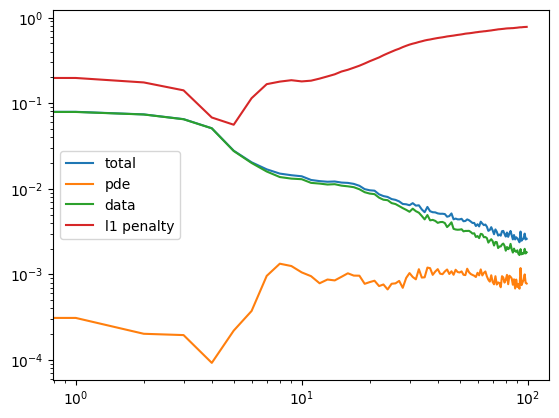

In [ ]:
plt.loglog(torch.arange(0, 100), torch.tensor(lt).view(100,-1).mean(dim=1), label='total')
plt.loglog(torch.arange(0, 100), torch.tensor(lp).view(100,-1).mean(dim=1), label='pde')
plt.loglog(torch.arange(0, 100), torch.tensor(ld).view(100,-1).mean(dim=1), label='data')
plt.loglog(torch.arange(0, 100), torch.tensor(ll).view(100,-1).mean(dim=1), label='l1 penalty')
plt.legend(loc='best')

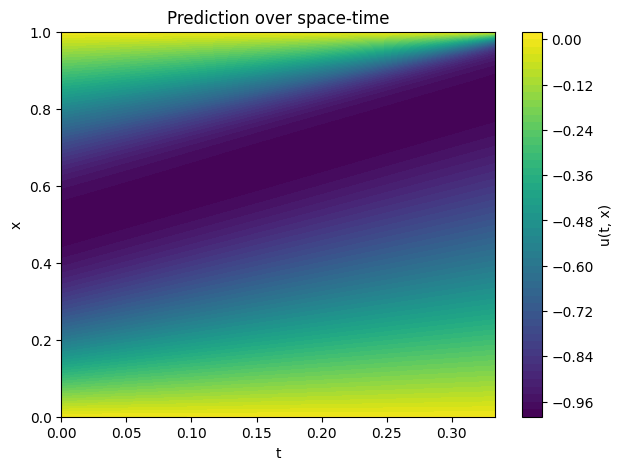

In [ ]:


# build grid (PyTorch)
Nx, Nt = 100, 100
X = torch.linspace(x_lower, x_upper, Nx)
T = torch.linspace(t_lower, t_upper, Nt)

xv = X.repeat_interleave(Nt).view(-1, 1)   # shape (Nx*Nt, 1)
tv = T.repeat(Nx).view(-1, 1)              # shape (Nx*Nt, 1)
xt = torch.cat([xv, tv], dim=1)            # (Nx*Nt, 2)

net = model.net.eval()
with torch.no_grad():                      # no grads needed for plotting
    U = net(xt)                            # (Nx*Nt, 1)

# reshape back to (Nx, Nt)
U_grid = U.detach().cpu().view(Nx, Nt).numpy()
t_grid = tv.detach().cpu().view(Nx, Nt).numpy()
x_grid = xv.detach().cpu().view(Nx, Nt).numpy()

plt.figure(figsize=(7, 5))
plt.contourf(t_grid, x_grid, U_grid, levels=50, cmap='viridis')
plt.colorbar(label='u(t, x)')
plt.xlabel('t')
plt.ylabel('x')
plt.title('Prediction over space-time')
plt.show()


In [ ]:
import numpy as np
t_vals = np.linspace(0, 0.9, 100)
x_vals = np.linspace(0, 1, 100)
T, X = np.meshgrid(t_vals, x_vals, indexing='ij')

# Flatten and convert to torch tensors
t_flat = torch.tensor(T.reshape(-1, 1), dtype=torch.float32)
x_flat = torch.tensor(X.reshape(-1, 1), dtype=torch.float32)

# Evaluate trainer.u over the grid (no grad needed)
# Use model.predict here
#u_pred = model.predict(xt)  # shape (batch_size, 1), float64
with torch.no_grad():
    U_pred = u_model1(t_flat, x_flat).cpu().numpy().reshape(T.shape)

# Plot
plt.figure(figsize=(7, 5))
plt.contourf(T, X, U, levels=50, cmap='viridis')
plt.colorbar(label='u(t, x)')
plt.xlabel('t') 
plt.ylabel('x')
plt.title('Prediction of trainer.u over space-time')
plt.show()


NameError: name 'u_model1' is not defined

In [ ]:
# Evaluate trainer.u over the grid (no grad needed)
with torch.no_grad():
    Ux_pred = torch.autograd.grad(trainer.u(t_flat, x_flat), x_flat, grad_outputs=torch.ones_like(trainer.u(t_flat, x_flat)), create_graph=True)[0].cpu().numpy().reshape(T.shape)

# Plot
plt.figure(figsize=(7, 5))
plt.contourf(T, X, Ux_pred, levels=50, cmap='viridis')
plt.colorbar(label='u_x(t, x)')
plt.xlabel('t')
plt.ylabel('x')
plt.title('Prediction of trainer.u_x over space-time')
plt.show()
